In [61]:
!conda i sklearn
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
iris = load_iris()#load and return data samples from iris flower dataset
dir(iris) #list attr and methods in iris

usage: conda [-h] [-v] [--no-plugins] [-V] COMMAND ...
conda: error: argument COMMAND: invalid choice: 'i' (choose from activate, build, clean, commands, compare, config, content-trust, convert, create, deactivate, debug, develop, doctor, env, export, index, info, init, inspect, install, list, metapackage, notices, pack, package, remove, rename, render, repo, repoquery, run, search, server, skeleton, token, tos, uninstall, update, upgrade)


['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [2]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [3]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [4]:
df['target'] = iris.target
df.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2
149,5.9,3.0,5.1,1.8,2


In [5]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [6]:
df[df.target==2].tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2
149,5.9,3.0,5.1,1.8,2


In [7]:
"""
0 :setosa
1 :versicolor
2 :virginica
"""

df['flower_name'] = df.target.apply(lambda x : iris.target_names[x]) #labeling the flower name with corresponding x's value nave
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,flower_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [8]:
%matplotlib inline 

In [9]:
df0 = df[df.target==0]
df1 = df[df.target==1]
df2 = df[df.target==2]

In [10]:
plt.xlabel("sepal length (cm)")
plt.ylabel("sepal width (cm)")
plt.scatter(df0['sepal length (cm)'], df0['sepal width (cm)'], color='red', marker='+')
plt.scatter(df1['sepal length (cm)'], df1['sepal width (cm)'], color='green', marker='.')

In [11]:
plt.xlabel("petal length (cm)")
plt.ylabel("petal width (cm)")
plt.scatter(df0['petal length (cm)'], df0['petal width (cm)'], color='red', marker='+')
plt.scatter(df1['petal length (cm)'], df1['petal width (cm)'], color='green', marker='.')

Spliting data into train and test

In [12]:
X = df.drop(['target', 'flower_name'], axis='columns')
X.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [13]:
Y = df.target
# filter_y = y[y==1]
# y.tail()

In [14]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

In [15]:
len(X_test) #20% of X

30

In [17]:
model = SVC(gamma=100, C=10, kernel='linear') #adj
model.fit(X_train, Y_train)

SVC(C=10, gamma=100, kernel='linear')

In [18]:
model.score(X_test, Y_test)

0.9666666666666667


(II). Train SVM classifier using sklearn digits dataset (i.e. from sklearn import load_digits) and then,
1. measure accuracy of your model using different kernels such as rbf, linear
2. Tune your model further using regularization and gamma parameters and try to come up with the highest accuracy score
3. Use 80% of samples as train size

In [72]:
from sklearn.datasets import load_digits
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, accuracy_score #reg metrics - MAE, MSE, MAPE

digits = load_digits()
digits.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

In [28]:
print("shape of data: ", digits.data.shape)
df = pd.DataFrame(digits.data, columns=digits.feature_names)
df.head()

shape of data:  (1797, 64)


,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0


In [38]:
X_train, X_test, Y_train, Y_test = train_test_split(
    digits.data, digits.target, test_size=0.2, random_state=42
) # (arrays, test_size, train_size, random_state, shuffle, stratify)

clf = LogisticRegression(max_iter=10000)
clf.fit(X_train, Y_train)

y_pred = clf.predict(X_test)
print("Accuracy: ", accuracy_score(Y_test, y_pred))

Accuracy:  0.975


In [58]:
model = SVC(kernel="rbf", gamma=0.001, C=1)
model.fit(X_train, Y_train)
y_pred = model.predict(X_test)
print("accuracy: ", accuracy_score(Y_test, y_pred))

accuracy:  0.9888888888888889


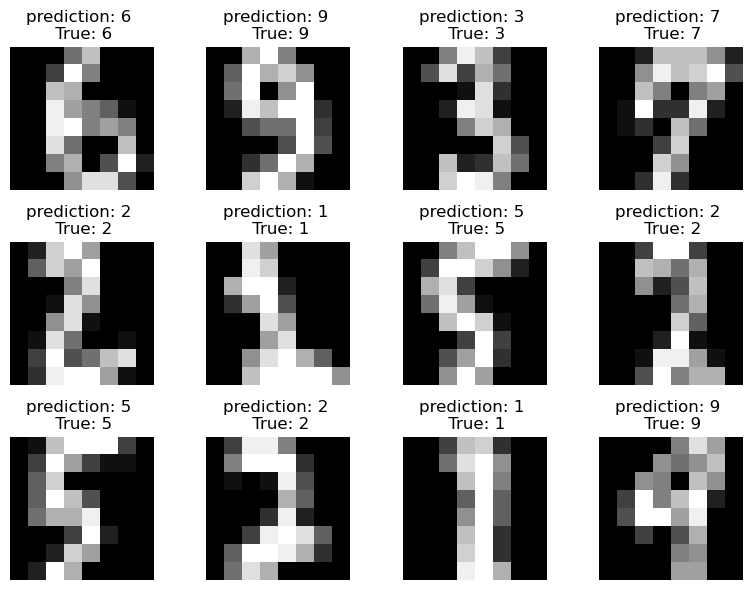

In [59]:
images = X_test.reshape(-1, 8, 8)

plt.figure(figsize=(8, 6))
for i in range(12):
    plt.subplot(3, 4, i+1)
    plt.imshow(images[i], cmap="gray")
    plt.title(f"prediction: {y_pred[i]} \n True: {Y_test[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

Tuning using GridSearchCV

In [74]:
#def C, gamma, kernel
param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": [0.001, 0.0001, 'scale', 'auto'],
    "kernel": ["rbf", "linear", "poly"]
}

#exhausive search over specified param vals => pick best
grid = GridSearchCV(
    SVC(),
    param_grid,
    refit=True,
    cv=5,
    n_jobs=-1,
    verbose=2
)
grid.fit(X_train, Y_train)
"""best params"""

print("best params: ", grid.best_params_)
Y_pred = grid.predict(X_test)

print("Accuracy: ", accuracy_score(Y_test, Y_pred))
print("\nClassification Report:\n", classification_report(Y_test, Y_pred))

Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV] END .....................C=0.1, gamma=0.001, kernel=rbf; total time=   0.2s
[CV] END ....................C=0.1, gamma=0.001, kernel=poly; total time=   0.1s
[CV] END .................C=0.1, gamma=0.0001, kernel=linear; total time=   0.1s
[CV] END ...................C=0.1, gamma=0.0001, kernel=poly; total time=   0.2s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.2s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   0.1s
[CV] END ......................C=0.1, gamma=auto, kernel=rbf; total time=   0.2s
[CV] END .......................C=1, gamma=0.001, kernel=rbf; total time=   0.1s
[CV] END ......................C=1, gamma=0.0001, kernel=rbf; total time=   0.1s
[CV] END ......................C=1, gamma=0.0001, kernel=rbf; total time=   0.1s
[CV] END ....................C=1, gamma=scale, kernel=linear; total time=   0.0s
[CV] END ....................C=1, gamma=scale, 

confusions matrix

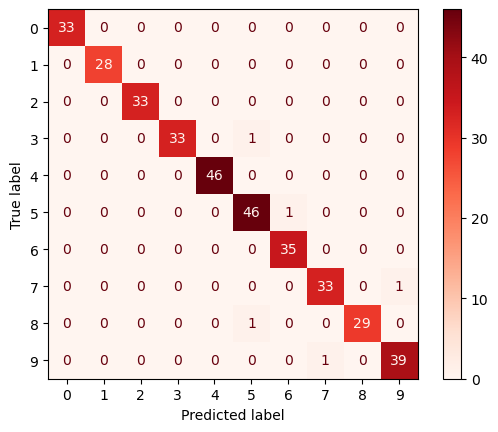

In [81]:
ConfusionMatrixDisplay.from_estimator(grid.best_estimator_, X_test, Y_test, cmap="Reds")
plt.show()